# Phân tách nguồn âm thanh (Music Source Separation) với DemucsLite trên máy cục bộ

Notebook này được cấu hình chạy trực tiếp trên laptop/máy trạm cá nhân, sử dụng thư mục dữ liệu `musdb18hq` đã giải nén sẵn.

## 1. Thiết lập thư mục và cấu trúc dự án

In [1]:
import os
import imageio_ffmpeg

# Lấy đường dẫn ffmpeg và thêm thư mục chứa nó vào PATH hệ thống
ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
ffmpeg_dir = os.path.dirname(ffmpeg_exe)
os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ["PATH"]

In [2]:
import os
from pathlib import Path

# Thư mục dự án là thư mục hiện tại chứa notebook
PROJECT_ROOT = Path(".").resolve()

# Đường dẫn tới thư mục musdb18hq đã giải nén trên máy của bạn
# Lưu ý: Thay đổi đường dẫn nếu bạn đặt ở ổ đĩa khác (ví dụ: Path("D:/musdb18hq"))
DATA_ROOT = PROJECT_ROOT / "musdb18hq"

DATA_DIR = PROJECT_ROOT / "data"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

DATA_DIR.mkdir(parents=True, exist_ok=True)
SCRIPTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATA_ROOT} (Tồn tại: {DATA_ROOT.exists()})")

Project root: D:\TDTU\HK7\Tài tử gặp Phong lưu
Dataset root: D:\TDTU\HK7\Tài tử gặp Phong lưu\musdb18hq (Tồn tại: True)


## 2. Kiến trúc mô hình DemucsLite (Giữ nguyên gốc)

In [3]:
%%writefile scripts/demucs_lite.py
"""
Kiến trúc mạng U-Net cơ sở dựa trên Demucs (tinh gọn)
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, stride)
        self.glu_conv = nn.Conv1d(out_channels, 2 * out_channels, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.conv(x))
        x = self.glu_conv(x)
        x = F.glu(x, dim=1)
        return x


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, is_last=False):
        super().__init__()
        self.glu_conv = nn.Conv1d(in_channels, 2 * in_channels, kernel_size=3, padding=1)
        self.deconv = nn.ConvTranspose1d(in_channels, out_channels, kernel_size, stride)
        self.is_last = is_last

    def forward(self, x, skip):
        x = x + skip
        x = self.glu_conv(x)
        x = F.glu(x, dim=1)
        x = self.deconv(x)
        if not self.is_last:
            x = F.relu(x)
        return x


class DemucsLite(nn.Module):
    def __init__(
        self,
        sources=4,
        audio_channels=2,
        channels=32,
        depth=5,
        growth=2,
        kernel_size=8,
        stride=4,
        lstm_layers=1,
    ):
        super().__init__()
        self.sources = sources
        self.audio_channels = audio_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.depth = depth

        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()

        in_ch = audio_channels
        out_ch = channels
        channel_sizes = []
        for i in range(depth):
            self.encoders.append(EncoderBlock(in_ch, out_ch, kernel_size, stride))
            channel_sizes.append(out_ch)
            in_ch = out_ch
            out_ch = int(out_ch * growth)

        bottleneck_ch = channel_sizes[-1]
        self.lstm = nn.LSTM(
            input_size=bottleneck_ch,
            hidden_size=bottleneck_ch,
            num_layers=lstm_layers,
            bidirectional=True,
            batch_first=True,
        )
        self.lstm_proj = nn.Linear(2 * bottleneck_ch, bottleneck_ch)

        rev_channels = list(reversed(channel_sizes))
        for i in range(depth):
            in_ch = rev_channels[i]
            if i + 1 < depth:
                out_ch = rev_channels[i + 1]
            else:
                out_ch = sources * audio_channels
            is_last = i == depth - 1
            self.decoders.append(DecoderBlock(in_ch, out_ch, kernel_size, stride, is_last))

    def valid_length(self, length):
        for _ in range(self.depth):
            length = math.ceil((length - self.kernel_size) / self.stride) + 1
            length = max(length, 1)
        for _ in range(self.depth):
            length = (length - 1) * self.stride + self.kernel_size
        return int(length)

    def forward(self, mixture):
        original_length = mixture.shape[-1]
        target_length = self.valid_length(original_length)
        pad_amount = target_length - original_length
        x = F.pad(mixture, (0, pad_amount))

        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)

        x_lstm = x.permute(0, 2, 1)
        x_lstm, _ = self.lstm(x_lstm)
        x_lstm = self.lstm_proj(x_lstm)
        x = x_lstm.permute(0, 2, 1)

        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip)

        x = x[..., :original_length]
        batch = x.shape[0]
        x = x.view(batch, self.sources, self.audio_channels, -1)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Overwriting scripts/demucs_lite.py


## 3. Tạo script quét dataset `scripts/verify_and_split_dataset.py`

In [4]:
%%writefile scripts/verify_and_split_dataset.py
import argparse
import csv
from pathlib import Path
import musdb
import soundfile as sf

EXPECTED_COUNTS = {"train": 100, "test": 50}
EXPECTED_SR = 44100
EXPECTED_CHANNELS = 2

def scan_subset(root: str, subset: str):
    mus = musdb.DB(root=root, is_wav=True, subsets=subset)
    records = []
    for track in mus:
        mix_path = Path(track.path)
        info = sf.info(str(mix_path))
        records.append({
            "track_name": track.name,
            "subset": subset,
            "duration_sec": round(info.duration, 2),
            "sample_rate": info.samplerate,
            "channels": info.channels,
            "path": str(mix_path.parent),
        })
    return records

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--root", required=True)
    parser.add_argument("--output", default="data/manifest.csv")
    parser.add_argument("--val-ratio", type=float, default=0.15)
    args = parser.parse_args()

    all_records = []
    for subset in ["train", "test"]:
        records = scan_subset(args.root, subset)
        print(f"[{subset.upper()}] Tìm thấy {len(records)} track.")
        all_records.extend(records)

    if args.val_ratio > 0:
        import random
        rng = random.Random(42)
        train_idx = [i for i, r in enumerate(all_records) if r["subset"] == "train"]
        rng.shuffle(train_idx)
        n_val = int(len(train_idx) * args.val_ratio)
        for i in train_idx[:n_val]:
            all_records[i]["subset"] = "val"
        print(f"Đã tách {n_val} track train sang validation.")

    out_path = Path(args.output)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(all_records[0].keys()))
        writer.writeheader()
        writer.writerows(all_records)
    print(f"Đã lưu manifest tại: {out_path}")

if __name__ == "__main__":
    main()

Overwriting scripts/verify_and_split_dataset.py


## 4. Kiểm tra và phân chia tập train/validation/test

In [5]:
!python scripts/verify_and_split_dataset.py \
    --root "{DATA_ROOT}" \
    --output data/manifest.csv \
    --val-ratio 0.15

[TRAIN] Tìm thấy 100 track.
[TEST] Tìm thấy 50 track.
Đã tách 15 track train sang validation.
Đã lưu manifest tại: data\manifest.csv


In [6]:
import pandas as pd
df = pd.read_csv('data/manifest.csv')
print(df['subset'].value_counts())

subset
train    85
test     50
val      15
Name: count, dtype: int64


## 5. Dataset và DataLoader (Tối ưu tài nguyên Laptop)

In [7]:
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import torch
from torch.utils.data import Dataset, DataLoader
import pitch_speed_perturb
 
SEED = 42
SAMPLE_RATE = 44100
SEGMENT_SECONDS = 10
BATCH_SIZE = 4
TRAIN_CROPS_PER_TRACK = 8
EVAL_CROPS_PER_TRACK = 8
NUM_WORKERS = 0
TARGET_SOURCES = ("vocals", "drums", "bass", "other")
REPORT_SOURCES = ("vocals", "drums", "bass")
 
# Xác suất áp dụng pitch/speed perturbation cho 1 sample (chỉ khi augment=True)
PITCH_SPEED_PROB = 0.3
PITCH_SPEED_RANGE = (0.9, 1.1)
 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
 
class MUSDBDataset(Dataset):
    def __init__(
        self,
        records,
        sources=TARGET_SOURCES,
        segment_seconds=SEGMENT_SECONDS,
        sample_rate=SAMPLE_RATE,
        random_crop=True,
        crops_per_track=1,
        augment=True,
    ):
        self.records = records[["track_name", "path"]].to_dict("records")
        self.sources = tuple(sources)
        self.sample_rate = sample_rate
        self.segment_length = int(segment_seconds * sample_rate)
        self.random_crop = random_crop
        self.crops_per_track = max(1, int(crops_per_track))
        self.augment = augment
 
    def __len__(self):
        return len(self.records) * self.crops_per_track
 
    def _read_segment(self, audio_path, start):
        audio, sample_rate = sf.read(
            str(audio_path),
            start=start,
            frames=self.segment_length,
            dtype="float32",
            always_2d=True,
        )
        if len(audio) < self.segment_length:
            audio = np.pad(
                audio,
                ((0, self.segment_length - len(audio)), (0, 0)),
                mode="constant",
            )
        return torch.from_numpy(np.ascontiguousarray(audio.T))
 
    def _apply_pitch_speed(self, targets):
        """
        targets: [sources, channels, T]. Áp dụng CHUNG 1 speed_factor và
        1 crop_start cho toàn bộ stem để giữ đúng quan hệ thời gian giữa
        chúng (nếu để mỗi stem tự chọn crop_start riêng sẽ bị lệch pha).
        """
        speed_factor = random.uniform(*PITCH_SPEED_RANGE)
        new_len = max(int(self.segment_length / speed_factor), 1)
        if new_len >= self.segment_length:
            crop_start = random.randint(0, new_len - self.segment_length)
        else:
            crop_start = 0
 
        perturbed = torch.stack([
            pitch_speed_perturb.pitch_speed_perturb(
                targets[i], speed_factor, self.segment_length, crop_start
            )
            for i in range(targets.shape[0])
        ])
        return perturbed
 
    def __getitem__(self, idx):
        record_idx = idx // self.crops_per_track
        crop_idx = idx % self.crops_per_track
        record = self.records[record_idx]
        track_dir = Path(record["path"])
        mixture_path = track_dir / "mixture.wav"
        total_frames = sf.info(str(mixture_path)).frames
        max_start = max(0, total_frames - self.segment_length)
        if self.random_crop:
            start = np.random.randint(0, max_start + 1)
        else:
            start = int(round(crop_idx * max_start / max(1, self.crops_per_track - 1)))
 
        targets = torch.stack([
            self._read_segment(track_dir / f"{source}.wav", start)
            for source in self.sources
        ])
 
        if self.augment:
            # Pitch/speed perturbation TRƯỚC gain augmentation
            if random.random() < PITCH_SPEED_PROB:
                targets = self._apply_pitch_speed(targets)
 
            gains_db = torch.empty(len(self.sources)).uniform_(-3.0, 3.0)
            gains = torch.pow(10.0, gains_db / 20.0).view(-1, 1, 1)
            targets = targets * gains
            mixture = targets.sum(dim=0)
            peak = mixture.abs().max().clamp_min(1.0)
            targets = targets / peak
            mixture = mixture / peak
        else:
            mixture = self._read_segment(mixture_path, start)
        return mixture, targets
 
manifest = pd.read_csv("data/manifest.csv")
train_records = manifest.loc[manifest["subset"] == "train"].reset_index(drop=True)
val_records = manifest.loc[manifest["subset"] == "val"].reset_index(drop=True)
test_records = manifest.loc[manifest["subset"] == "test"].reset_index(drop=True)
 
train_dataset = MUSDBDataset(train_records, random_crop=True, crops_per_track=TRAIN_CROPS_PER_TRACK, augment=True)
# FIX: thêm augment=False rõ ràng cho val/test (bản gốc thiếu, dùng nhầm mặc định augment=True)
val_dataset = MUSDBDataset(val_records, random_crop=False, crops_per_track=EVAL_CROPS_PER_TRACK, augment=False)
test_dataset = MUSDBDataset(test_records, random_crop=False, crops_per_track=EVAL_CROPS_PER_TRACK, augment=False)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
 
print(f"Đã nạp {len(train_dataset)} mẫu train, {len(val_dataset)} mẫu val, {len(test_dataset)} mẫu test.")

Đã nạp 680 mẫu train, 120 mẫu val, 400 mẫu test.


## 6. Định nghĩa Loss & Tiện ích đánh giá

In [8]:
import math
import torch
import torch.nn.functional as F
 
EPS = 1e-8
SI_SDR_SILENCE_THRESHOLD_DB = -40.0

DEFAULT_LOSS_WEIGHTS = {
    "consistency_weight": 0.10,
    "spectral_weight": 0.08,  # tăng từ 0.05
    "leakage_weight": 0.10, # tăng từ 0.02 - thay đổi quan trọng nhất
    "si_sdr_weight": 0.002,  # MỚI - bắt đầu nhỏ, tăng dần nếu cần
}
_WINDOW_CACHE = {}
 
def _hann_window(n_fft, device):
    key = (n_fft, str(device))
    if key not in _WINDOW_CACHE:
        _WINDOW_CACHE[key] = torch.hann_window(n_fft, device=device, dtype=torch.float32)
    return _WINDOW_CACHE[key]
 
def multi_resolution_stft_loss(estimate, target, fft_sizes=(256, 512, 1024), eps=EPS):
    # THAY ĐỔI: thêm 256 vào fft_sizes để nhạy hơn với lỗi tần số cao
    estimate = estimate.float().mean(dim=-2).reshape(-1, estimate.shape[-1])
    target = target.float().mean(dim=-2).reshape(-1, target.shape[-1])
    total = estimate.new_tensor(0.0)
    for n_fft in fft_sizes:
        hop = n_fft // 4
        window = _hann_window(n_fft, estimate.device)
        est_mag = torch.stft(estimate, n_fft, hop, window=window, return_complex=True).abs()
        tgt_mag = torch.stft(target, n_fft, hop, window=window, return_complex=True).abs()
        spectral_convergence = (est_mag - tgt_mag).norm() / (tgt_mag.norm() + eps)
        log_magnitude = F.l1_loss(torch.log1p(est_mag), torch.log1p(tgt_mag))
        total = total + spectral_convergence + log_magnitude
    return total / len(fft_sizes)
 
def leakage_residual_loss(estimate, target, eps=EPS):
    # KHÔNG đổi logic - chỉ tăng trọng số khi gọi (leakage_weight) ở separation_loss
    residual = (estimate - target).float().flatten(start_dim=2)
    nuisance = target.float().flatten(start_dim=2)
    dot = torch.einsum("bin,bjn->bij", residual, nuisance)
    denom = (residual.square().sum(-1)[:, :, None] * nuisance.square().sum(-1)[:, None, :])
    corr_squared = dot.square() / (denom + eps)
    mask = ~torch.eye(corr_squared.shape[-1], dtype=torch.bool, device=corr_squared.device)
    return corr_squared[:, mask].mean()
 
def leakage_db(estimate, target, eps=EPS):
    value = leakage_residual_loss(estimate, target, eps=eps)
    return 10.0 * torch.log10(value + eps)
 
def si_sdr_loss(estimate, target, eps=EPS, silence_threshold_db=SI_SDR_SILENCE_THRESHOLD_DB):
    """
    estimate, target: [B, sources, channels, T]
    Trả về: loss cần MINIMIZE (âm của SI-SDR trung bình trên các entry active).
    """
    b, s, c, t = estimate.shape
    est = estimate.float().reshape(b * s, c * t)
    tgt = target.float().reshape(b * s, c * t)
 
    # Zero-mean theo thời gian+kênh (chuẩn SI-SDR)
    est = est - est.mean(dim=-1, keepdim=True)
    tgt = tgt - tgt.mean(dim=-1, keepdim=True)
 
    tgt_energy = tgt.pow(2).sum(dim=-1)  # [B*sources]
 
    # Ngưỡng im lặng - GIỐNG HỆT cách tính ở sdr_per_source_db_masked (eval)
    n_samples = c * t
    silence_energy_threshold = n_samples * (10.0 ** (silence_threshold_db / 10.0))
    active = tgt_energy > silence_energy_threshold  # [B*sources] bool
 
    if active.sum() == 0:
        # Không có entry nào đủ tín hiệu trong batch này -> không đóng góp gradient
        return estimate.new_zeros(())
 
    est_active = est[active]
    tgt_active = tgt[active]
    tgt_energy_active = tgt_energy[active] + eps
 
    dot = (est_active * tgt_active).sum(dim=-1)
    proj = (dot / tgt_energy_active).unsqueeze(-1) * tgt_active
    noise = est_active - proj
 
    si_sdr_val = 10.0 * torch.log10(
        (proj.pow(2).sum(dim=-1) + eps) / (noise.pow(2).sum(dim=-1) + eps)
    )
    return -si_sdr_val.mean()  # minimize -> maximize SI-SDR thật trên phần có tín hiệu
 
def separation_loss(
    estimate, target, mixture,
    consistency_weight=0.10, spectral_weight=0.08, leakage_weight=0.10, si_sdr_weight=0.01,
):
    source_l1 = F.l1_loss(estimate, target)
    mixture_l1 = F.l1_loss(estimate.sum(dim=1), mixture)
    spectral = multi_resolution_stft_loss(estimate, target) if spectral_weight > 0 else source_l1.new_zeros(())
    leakage = leakage_residual_loss(estimate, target) if leakage_weight > 0 else source_l1.new_zeros(())
    si_sdr = si_sdr_loss(estimate, target) if si_sdr_weight > 0 else source_l1.new_zeros(())
 
    total = (
        source_l1
        + consistency_weight * mixture_l1
        + spectral_weight * spectral
        + leakage_weight * leakage
        + si_sdr_weight * si_sdr
    )
    return total, {
        "source_l1": source_l1.detach(),
        "mixture_l1": mixture_l1.detach(),
        "spectral": spectral.detach(),
        "leakage": leakage.detach(),
        "si_sdr": si_sdr.detach(),  # theo dõi riêng để biết có cần tăng si_sdr_weight không
    }
 
def sdr_per_source_db(estimate, target, eps=EPS):
    target_energy = target.pow(2).sum(dim=(-2, -1))
    error_energy = (target - estimate).pow(2).sum(dim=(-2, -1))
    return 10.0 * torch.log10((target_energy + eps) / (error_energy + eps))
 
def sdr_db(estimate, target, eps=EPS):
    return sdr_per_source_db(estimate, target, eps=eps).mean()

## 7. Huấn luyện và lưu Checkpoint cục bộ

In [ ]:
import os
import time
import shutil
from datetime import datetime
from contextlib import nullcontext
 
import pandas as pd
import torch
import torch.optim as optim
from tqdm.auto import tqdm
from scripts.demucs_lite import DemucsLite
 
# CẤU HÌNH
EPOCHS = 150
LEARNING_RATE = 3e-4 # nếu RESUME_MODE = "weights_only", nên dùng ~1e-4
WEIGHT_DECAY = 1e-2
GRAD_CLIP = 1.0
MODEL_CHANNELS = 32
MODEL_DEPTH = 5
REMIX_PROB = 0.5
 
SCHED_PATIENCE = 5
MIN_LR = 1e-5 # sàn LR cho ReduceLROnPlateau
EARLY_STOP_PATIENCE = 15 # dừng nếu val_loss không cải thiện sau ngần này epoch (0 = tắt)
 
RESUME_MODE = "scratch"     # "scratch" | "weights_only" | "full"
INIT_WEIGHTS_FROM = "checkpoints/demucs_lite_last.pth"# chỉ dùng cho "weights_only"
 
SILENCE_THRESHOLD_DB = -40.0
_EPS = 1e-8
 
SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
LAST_CHECKPOINT = os.path.join(SAVE_DIR, "demucs_lite_last.pth")
BEST_CHECKPOINT = os.path.join(SAVE_DIR, "demucs_lite_best.pth")
BEST_SDR_CHECKPOINT = os.path.join(SAVE_DIR, "demucs_lite_best_sdr.pth")
HISTORY_PATH = os.path.join(SAVE_DIR, "training_history.csv")
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (device.type == "cuda")
CURRENT_LOSS_CONFIG = dict(DEFAULT_LOSS_WEIGHTS)
 
 
# TIỆN ÍCH
def amp_context():
    return torch.amp.autocast('cuda', dtype=torch.float16) if use_amp else nullcontext()
 
 
def remix_batch(mixture, target, remix_prob=REMIX_PROB):
    """
    target: [B, sources, channels, T]. Với mỗi source, xác suất remix_prob sẽ
    hoán vị source đó giữa các track trong batch, rồi tính lại mixture = tổng.
    """
    B, S, C, T = target.shape
    new_target = target.clone()
    for s in range(S):
        if torch.rand(1).item() < remix_prob:
            perm = torch.randperm(B, device=target.device)
            new_target[:, s] = target[perm, s]
    return new_target.sum(dim=1), new_target
 
 
def sdr_per_source_db_masked(estimate, target, eps=_EPS, silence_threshold_db=SILENCE_THRESHOLD_DB):
    """SDR theo (batch_item, source) + mask False cho đoạn target gần như im lặng."""
    target_energy = target.pow(2).sum(dim=(-2, -1))
    error_energy = (target - estimate).pow(2).sum(dim=(-2, -1))
    n_samples = target.shape[-1] * target.shape[-2]
    threshold = n_samples * (10.0 ** (silence_threshold_db / 10.0))
    active = target_energy > threshold
    sdr = 10.0 * torch.log10((target_energy + eps) / (error_energy + eps))
    return sdr, active
 
 
def archive_existing_checkpoints():
    """Chuyển checkpoint/history hiện có vào thư mục archive_<thời gian> (không xoá)."""
    existing = [p for p in (LAST_CHECKPOINT, BEST_CHECKPOINT, BEST_SDR_CHECKPOINT, HISTORY_PATH)
                if os.path.isfile(p)]
    if not existing:
        return
    archive_dir = os.path.join(SAVE_DIR, "archive_" + datetime.now().strftime("%Y%m%d_%H%M%S"))
    os.makedirs(archive_dir, exist_ok=True)
    for path in existing:
        shutil.move(path, os.path.join(archive_dir, os.path.basename(path)))
    print(f"Đã chuyển {len(existing)} file cũ vào: {archive_dir}")
 
 
# MODEL / OPTIMIZER
train_model = DemucsLite(
    sources=len(TARGET_SOURCES),
    audio_channels=2,
    channels=MODEL_CHANNELS,
    depth=MODEL_DEPTH,
).to(device)
 
optimizer = optim.AdamW(train_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=SCHED_PATIENCE, min_lr=MIN_LR
)
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
 
 
# TRAIN / VALIDATE
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    total_items = 0
    comp_sums = {}
    progress = tqdm(loader, desc="Train", leave=False)
 
    for mixture, target in progress:
        mixture = mixture.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        mixture, target = remix_batch(mixture, target, REMIX_PROB)
        optimizer.zero_grad(set_to_none=True)
 
        with amp_context():
            estimate = model(mixture)
            loss, parts = separation_loss(estimate, target, mixture, **DEFAULT_LOSS_WEIGHTS)
 
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
 
        bs = mixture.size(0)
        total_loss += loss.item() * bs
        total_items += bs
        for k, v in parts.items():
            comp_sums[k] = comp_sums.get(k, 0.0) + v.float() * bs
        progress.set_postfix(loss=f"{loss.item():.4f}", grad=f"{float(grad_norm):.2f}")
 
    n = max(total_items, 1)
    comps = {k: float(v) / n for k, v in comp_sums.items()}
    return total_loss / n, comps
 
 
@torch.no_grad()
def validate(model, loader):
    model.eval()
    n_src = len(TARGET_SOURCES)
    total_loss = 0.0
    total_items = 0
    comp_sums = {}
    sdr_sum = torch.zeros(n_src, dtype=torch.float64)
    raw_sum = torch.zeros(n_src, dtype=torch.float64)
    active_cnt = torch.zeros(n_src, dtype=torch.float64)
 
    for mixture, target in tqdm(loader, desc="Validation", leave=False):
        mixture = mixture.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        with amp_context():
            estimate = model(mixture)
            loss, parts = separation_loss(estimate, target, mixture, **DEFAULT_LOSS_WEIGHTS)
 
        bs = mixture.size(0)
        total_loss += loss.item() * bs
        total_items += bs
        for k, v in parts.items():
            comp_sums[k] = comp_sums.get(k, 0.0) + v.float() * bs
 
        est32, tgt32 = estimate.float(), target.float()
        sdr, active = sdr_per_source_db_masked(est32, tgt32)
        sdr_sum += (sdr * active.float()).sum(dim=0).double().cpu()
        active_cnt += active.sum(dim=0).double().cpu()
        raw_sum += sdr_per_source_db(est32, tgt32).sum(dim=0).double().cpu()
 
    n = max(total_items, 1)
    sdr_by_source = sdr_sum / active_cnt.clamp(min=1) # SDR đã lọc im lặng
    active_ratio = active_cnt / n # % đoạn có tín hiệu
    raw_by_source = raw_sum / n # SDR chưa lọc (nối tiếp log cũ)
 
    result = {
        "loss": total_loss / n,
        "sdr_db": sdr_by_source.mean().item(),
        "sdr_raw_db": raw_by_source.mean().item(),
        "parts": {k: float(v) / n for k, v in comp_sums.items()},
    }
    for i, name in enumerate(TARGET_SOURCES):
        result[f"sdr_{name}_db"] = sdr_by_source[i].item()
        result[f"active_{name}"] = active_ratio[i].item()
    return result
 
 
# KHỞI TẠO / RESUME
start_epoch = 1
best_val_loss = float("inf")
best_val_sdr = float("-inf")
epochs_since_best = 0
history = []
 
if RESUME_MODE == "full":
    if not os.path.isfile(LAST_CHECKPOINT):
        raise FileNotFoundError(f"Không thấy {LAST_CHECKPOINT} để resume 'full'.")
    ckpt = torch.load(LAST_CHECKPOINT, map_location=device, weights_only=False)
    saved_cfg = ckpt.get("loss_config")
    if saved_cfg is None:
        print("CẢNH BÁO: checkpoint này không lưu loss_config nên không kiểm tra được công thức loss. "
              "Nếu loss đã đổi từ lúc lưu, hãy dùng RESUME_MODE = 'weights_only'.")
    elif saved_cfg != CURRENT_LOSS_CONFIG:
        raise ValueError(
            "Công thức loss hiện tại KHÁC với lúc lưu checkpoint:\n"
            f"  lúc lưu : {saved_cfg}\n  hiện tại: {CURRENT_LOSS_CONFIG}\n"
            "Resume 'full' sẽ làm scheduler/best_val_loss sai. Hãy dùng 'weights_only' hoặc 'scratch'."
        )
    train_model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    if "scaler_state_dict" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_val_loss = ckpt.get("best_val_loss", float("inf"))
    best_val_sdr = ckpt.get("best_val_sdr", float("-inf"))
    epochs_since_best = ckpt.get("epochs_since_best", 0)
    history = ckpt.get("history", [])
    print(f"[full] Tiếp tục từ epoch {ckpt['epoch']}.")
 
elif RESUME_MODE == "weights_only":
    ckpt = torch.load(INIT_WEIGHTS_FROM, map_location=device, weights_only=False)
    train_model.load_state_dict(ckpt["model_state_dict"])
    archive_existing_checkpoints()
    print(f"[weights_only] Đã nạp trọng số từ {INIT_WEIGHTS_FROM} (epoch {ckpt.get('epoch', '?')}); "
          f"optimizer/scheduler/best bắt đầu mới, LR = {LEARNING_RATE:g}.")
 
elif RESUME_MODE == "scratch":
    archive_existing_checkpoints()
    print("[scratch] Bắt đầu train từ đầu.")
 
else:
    raise ValueError("RESUME_MODE phải là 'scratch', 'weights_only' hoặc 'full'.")
 
 
# VÒNG LẶP HUẤN LUYỆN
for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start = time.perf_counter()
    train_loss, train_parts = train_one_epoch(train_model, train_loader)
    val = validate(train_model, val_loader)
 
    lr_used = optimizer.param_groups[0]["lr"]   # LR đã dùng trong epoch này
    scheduler.step(val["loss"])
    epoch_time_sec = time.perf_counter() - epoch_start
 
    is_best = val["loss"] < best_val_loss
    if is_best:
        best_val_loss = val["loss"]
        epochs_since_best = 0
    else:
        epochs_since_best += 1
 
    is_best_sdr = val["sdr_db"] > best_val_sdr
    if is_best_sdr:
        best_val_sdr = val["sdr_db"]
 
    row = {
        "epoch": epoch,
        "lr": lr_used,
        "train_loss": train_loss,
        "val_loss": val["loss"],
        "val_sdr_db": val["sdr_db"],
        "val_sdr_raw_db": val["sdr_raw_db"],
    }
    for name in TARGET_SOURCES:
        row[f"sdr_{name}_db"] = val[f"sdr_{name}_db"]
    for name in TARGET_SOURCES:
        row[f"active_{name}"] = val[f"active_{name}"]
    for k, v in train_parts.items():
        row[f"train_{k}"] = v
    for k, v in val["parts"].items():
        row[f"val_{k}"] = v
    row["time_sec"] = epoch_time_sec
    history.append(row)
    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)
 
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": train_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_loss": best_val_loss,
        "best_val_sdr": best_val_sdr,
        "epochs_since_best": epochs_since_best,
        "loss_config": CURRENT_LOSS_CONFIG,
        "model_config": {"channels": MODEL_CHANNELS, "depth": MODEL_DEPTH},
        "history": history,
    }
    torch.save(checkpoint, LAST_CHECKPOINT)
    if is_best:
        torch.save(checkpoint, BEST_CHECKPOINT)
    if is_best_sdr:
        torch.save(checkpoint, BEST_SDR_CHECKPOINT)
 
    per_stem = " | ".join(f"{n}: {val[f'sdr_{n}_db']:.2f}dB" for n in TARGET_SOURCES)
    vp = val["parts"]
    print(
        f"Epoch {epoch:03d}/{EPOCHS} | LR {lr_used:.2e} | Train {train_loss:.4f} | Val {val['loss']:.4f} "
        f"| SDR(lọc im lặng) {val['sdr_db']:.2f}dB | {per_stem} | {epoch_time_sec:.0f}s"
    )
    print(
        "    val thành phần: "
        + " | ".join(f"{k} {vp[k]:.4f}" for k in ("source_l1", "spectral", "leakage", "si_sdr") if k in vp)
        + f"   {'[best loss]' if is_best else ''} {'[best SDR]' if is_best_sdr else ''}"
    )
 
    if EARLY_STOP_PATIENCE and epochs_since_best >= EARLY_STOP_PATIENCE:
        print(f"Dừng sớm: val_loss không cải thiện sau {EARLY_STOP_PATIENCE} epoch.")
        break
 

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[full] Tiếp tục từ epoch 3.


Epoch 004/200 | LR 1.00e-04 | Train 0.0746 | Val 0.0848 | SDR(lọc im lặng) 2.07dB | vocals: -2.65dB | drums: 3.95dB | bass: 3.55dB | other: 3.44dB | 1024s
    val thành phần: source_l1 0.0302 | spectral 0.5959 | leakage 0.0440 | si_sdr -0.5680    


Epoch 005/200 | LR 1.00e-04 | Train 0.0743 | Val 0.0844 | SDR(lọc im lặng) 2.01dB | vocals: -2.79dB | drums: 3.88dB | bass: 3.42dB | other: 3.52dB | 1051s
    val thành phần: source_l1 0.0305 | spectral 0.5888 | leakage 0.0415 | si_sdr -0.5976    


Epoch 006/200 | LR 1.00e-04 | Train 0.0739 | Val 0.0845 | SDR(lọc im lặng) 2.06dB | vocals: -2.63dB | drums: 4.04dB | bass: 3.54dB | other: 3.29dB | 1054s
    val thành phần: source_l1 0.0301 | spectral 0.5960 | leakage 0.0418 | si_sdr -0.5179    


...

Epoch 049/200 | LR 1.25e-05 | Train 0.0733 | Val 0.0826 | SDR(lọc im lặng) 2.12dB | vocals: -3.12dB | drums: 4.14dB | bass: 3.76dB | other: 3.70dB | 1601s
    val thành phần: source_l1 0.0303 | spectral 0.5764 | leakage 0.0388 | si_sdr -0.9453    


Epoch 050/200 | LR 1.25e-05 | Train 0.0720 | Val 0.0819 | SDR(lọc im lặng) 2.17dB | vocals: -2.97dB | drums: 4.15dB | bass: 3.79dB | other: 3.71dB | 1624s
    val thành phần: source_l1 0.0301 | spectral 0.5732 | leakage 0.0396 | si_sdr -0.9720   [best loss] 


Epoch 051/200 | LR 1.25e-05 | Train 0.0725 | Val 0.0825 | SDR(lọc im lặng) 2.12dB | vocals: -3.07dB | drums: 4.12dB | bass: 3.74dB | other: 3.71dB | 1682s
    val thành phần: source_l1 0.0303 | spectral 0.5754 | leakage 0.0388 | si_sdr -0.9080    


Epoch 052/200 | LR 1.25e-05 | Train 0.0742 | Val 0.0829 | SDR(lọc im lặng) 2.10dB | vocals: -3.16dB | drums: 4.14dB | bass: 3.76dB | other: 3.64dB | 1613s
    val thành phần: source_l1 0.0304 | spectral 0.5772 | leakage 0.0381 | si_sdr -0.8844    


KeyboardInterrupt: 

## 8. Tinh chỉnh Hyperparameters (Đã sửa lỗi autograd RuntimeError)

In [ ]:
import gc

RUN_HYPERPARAMETER_SEARCH = True
TUNE_EPOCHS = 1
TUNE_MAX_TRAIN_BATCHES = 10
TUNE_MAX_VAL_BATCHES = 5

HYPERPARAMETER_CANDIDATES = [
    {"name": "fast", "channels": 24, "depth": 4, "lr": 5e-4, "consistency_weight": 0.10, "spectral_weight": 0.03, "leakage_weight": 0.01},
    {"name": "balanced", "channels": 32, "depth": 5, "lr": 3e-4, "consistency_weight": 0.10, "spectral_weight": 0.05, "leakage_weight": 0.02},
]

# Batch giả lập độc lập để đo RTF an toàn
dummy_bench = torch.randn(1, 2, int(3 * SAMPLE_RATE), device=device)

@torch.no_grad()
def benchmark_speed(model, sample_input, repeats=5):
    model.eval()
    latencies = []
    for _ in range(repeats):
        start = time.perf_counter()
        with amp_context():
            _ = model(sample_input)
        if device.type == "cuda":
            torch.cuda.synchronize()
        latencies.append(time.perf_counter() - start)
    return float(np.mean(latencies))

def train_short_trial(model, optimizer, scaler, config):
    model.train()
    running_loss = 0.0
    item_count = 0
    for batch_idx, (mixture, target) in enumerate(train_loader):
        if batch_idx >= TUNE_MAX_TRAIN_BATCHES:
            break
        # Tách biệt tensor khỏi buffer bằng .clone()
        mixture = mixture.to(device, non_blocking=True).clone()
        target = target.to(device, non_blocking=True).clone()
        
        optimizer.zero_grad(set_to_none=True)
        with amp_context():
            estimate = model(mixture)
            loss, _ = separation_loss(
                estimate, target, mixture,
                consistency_weight=config["consistency_weight"],
                spectral_weight=config["spectral_weight"],
                leakage_weight=config["leakage_weight"]
            )
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * mixture.shape[0]
        item_count += mixture.shape[0]
    return running_loss / max(item_count, 1)

@torch.no_grad()
def validate_short_trial(model, config):
    model.eval()
    loss_sum = 0.0
    item_count = 0
    for batch_idx, (mixture, target) in enumerate(val_loader):
        if batch_idx >= TUNE_MAX_VAL_BATCHES:
            break
        mixture = mixture.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        with amp_context():
            estimate = model(mixture)
            loss, _ = separation_loss(
                estimate, target, mixture,
                consistency_weight=config["consistency_weight"],
                spectral_weight=config["spectral_weight"],
                leakage_weight=config["leakage_weight"]
            )
        loss_sum += loss.item() * mixture.shape[0]
        item_count += mixture.shape[0]
    return {"val_loss": loss_sum / max(item_count, 1)}

def run_trial(config):
    model = DemucsLite(
        sources=len(TARGET_SOURCES), audio_channels=2,
        channels=config["channels"], depth=config["depth"],
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=WEIGHT_DECAY)
    trial_scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    
    for _ in range(TUNE_EPOCHS):
        last_loss = train_short_trial(model, optimizer, trial_scaler, config)
    
    val_res = validate_short_trial(model, config)
    lat = benchmark_speed(model, dummy_bench, repeats=5)
    rtf = lat / (dummy_bench.shape[-1] / SAMPLE_RATE)
    
    del model, optimizer, trial_scaler
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return {**config, "train_loss": last_loss, **val_res, "latency_ms": lat * 1000, "rtf": rtf}

if RUN_HYPERPARAMETER_SEARCH:
    results = [run_trial(cfg) for cfg in HYPERPARAMETER_CANDIDATES]
    df_tune = pd.DataFrame(results)
    print("\nKết quả thử nghiệm:")
    print(df_tune[["name", "channels", "depth", "train_loss", "val_loss", "latency_ms", "rtf"]])


Kết quả thử nghiệm:
       name  channels  depth  train_loss  val_loss  latency_ms       rtf
0      fast        24      4    0.558354  0.504707   767.03584  0.255679
1  balanced        32      5    0.553580  0.525051   424.23738  0.141412


Vẽ biểu đồ trực quan so sánh wav

Đang xử lý stem: vocals...
Đang xử lý stem: drums...
Đang xử lý stem: bass...
Đang xử lý stem: other...


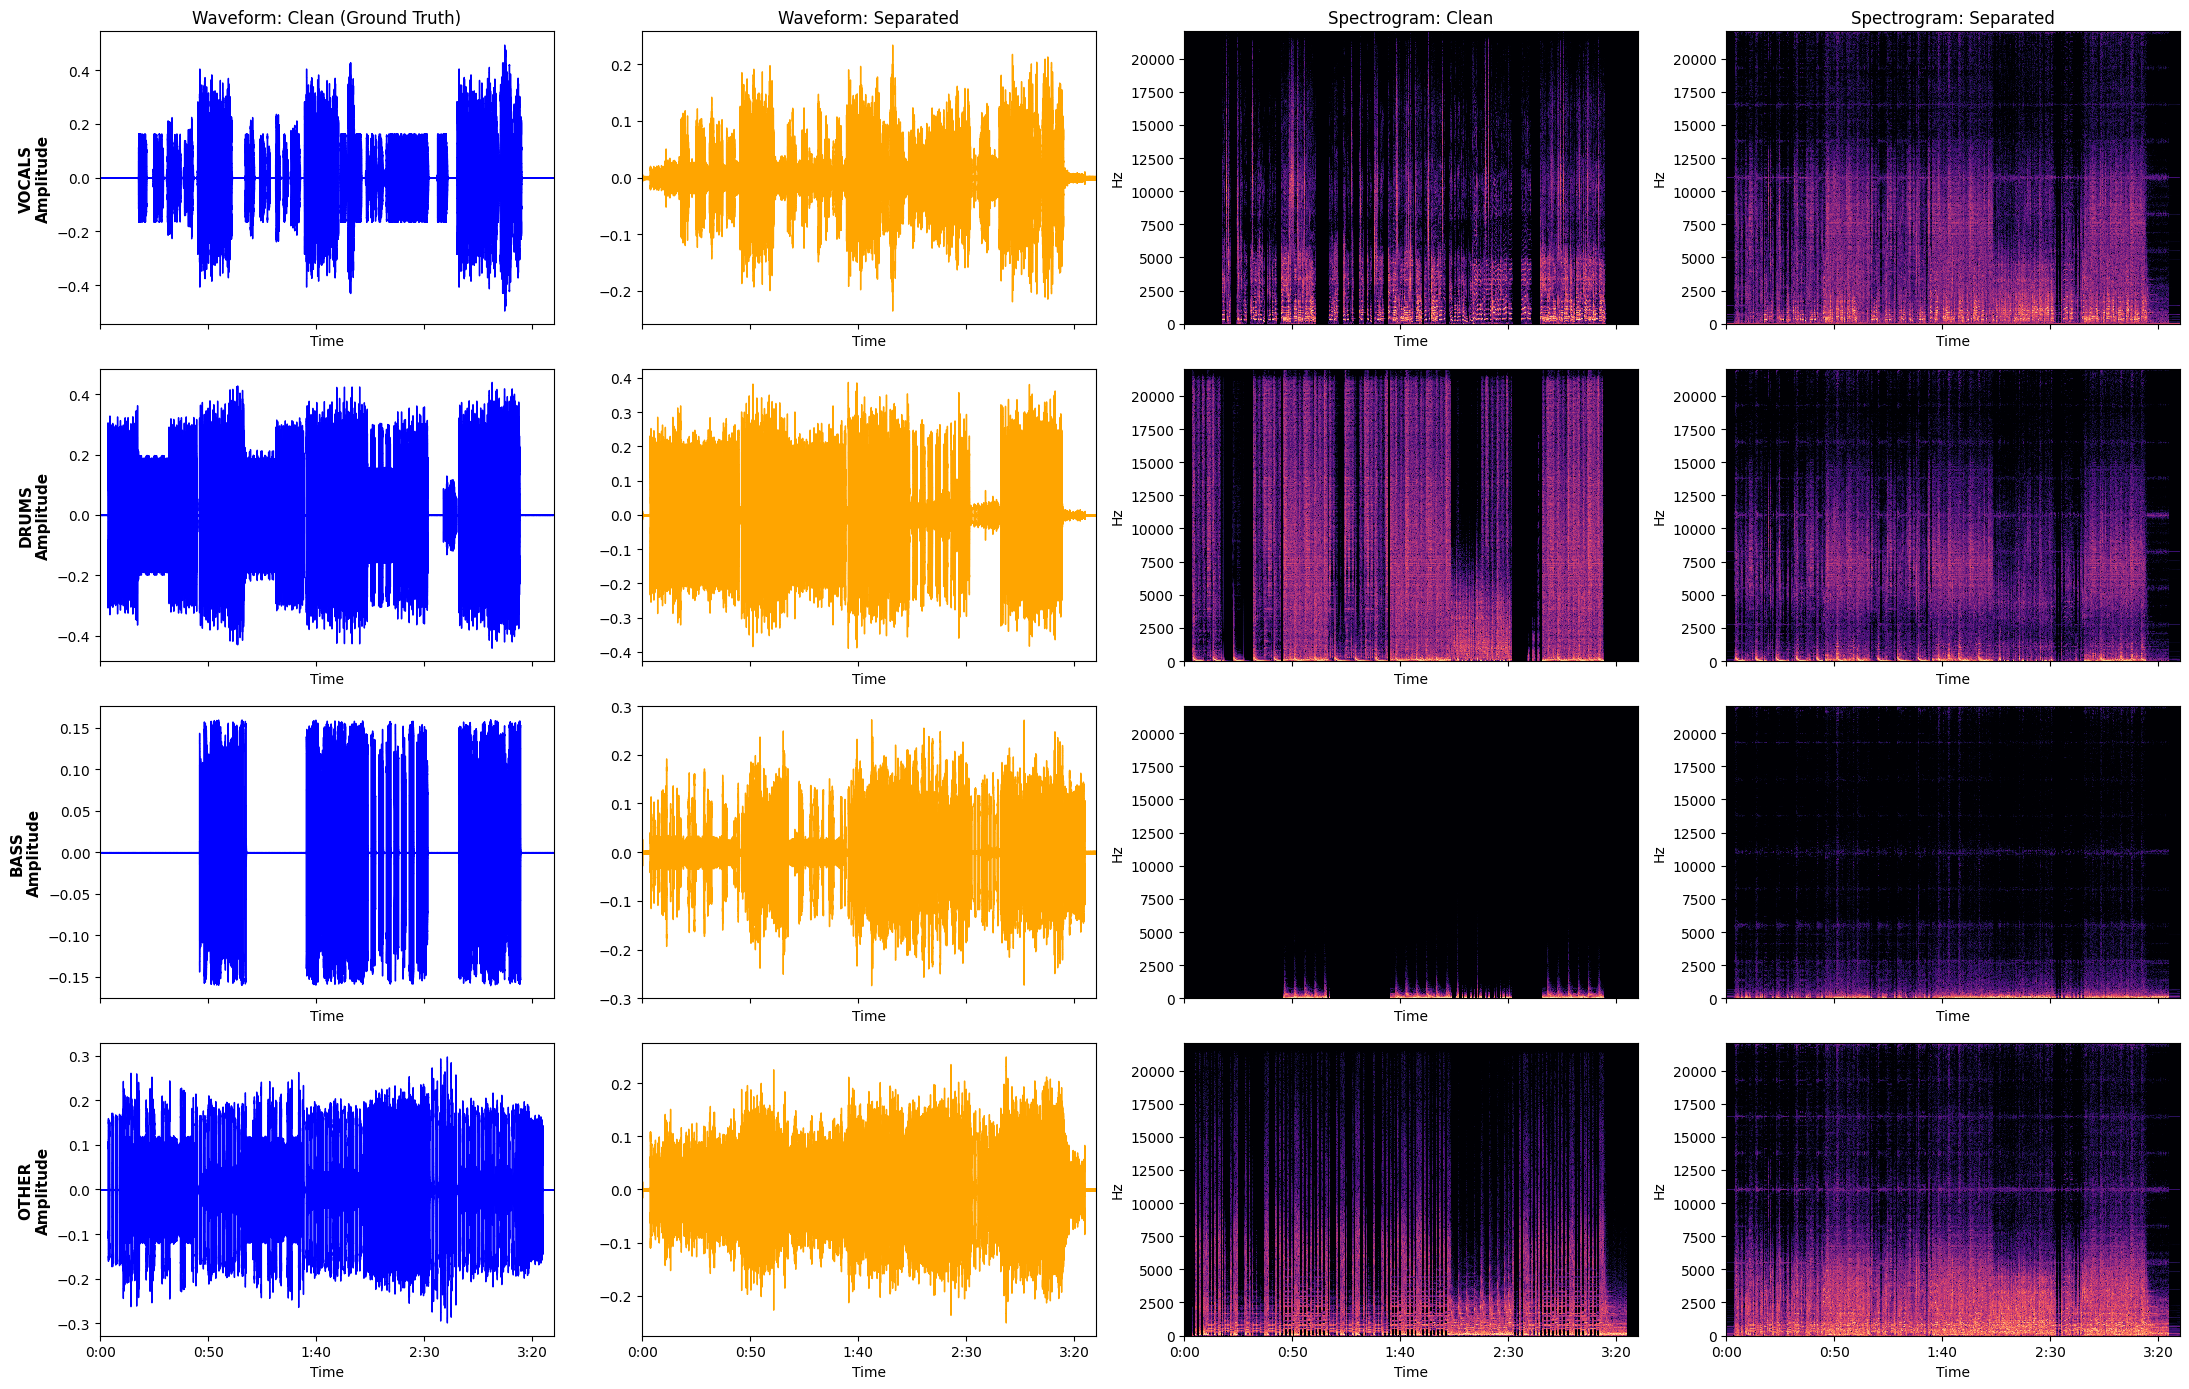

In [ ]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. Định nghĩa thư mục gốc chứa các file stem
CLEAN_DIR = "musdb18hq/test/AM Contra - Heart Peripheral"
ESTIMATED_DIR = "MUSIC_API/storage/results/aca185f3-e4c4-4c95-aada-c26d57accbc0"

# 4 stems chuẩn của MUSDB18
STEMS = ["vocals", "drums", "bass", "other"]

# 2. Khởi tạo khung vẽ: 4 hàng (4 stems) x 4 cột (Wave Clean, Wave Est, Spec Clean, Spec Est)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(22, 14), sharex=True)

for i, stem in enumerate(STEMS):
    clean_path = os.path.join(CLEAN_DIR, f"{stem}.wav")
    est_path = os.path.join(ESTIMATED_DIR, f"{stem}.wav")

    # Kiểm tra tồn tại của file trước khi load
    if not os.path.exists(clean_path) or not os.path.exists(est_path):
        print(f"⚠️ Cảnh báo: Không tìm thấy file của stem '{stem}', bỏ qua.")
        continue

    print(f"Đang xử lý stem: {stem}...")

    # Load audio
    y_clean, sr = librosa.load(clean_path, sr=None)
    y_est, _ = librosa.load(est_path, sr=sr)

    # Cắt ngắn mảng để đồng bộ số lượng mẫu nếu có sai lệch nhỏ
    min_len = min(len(y_clean), len(y_est))
    y_clean = y_clean[:min_len]
    y_est = y_est[:min_len]

    # Tính Spectrogram (dB)
    D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)
    D_est = librosa.amplitude_to_db(np.abs(librosa.stft(y_est)), ref=np.max)

    # --- Cột 0: Waveform Clean ---
    librosa.display.waveshow(y_clean, sr=sr, ax=axes[i, 0], color='blue')
    axes[i, 0].set_ylabel(f"{stem.upper()}\nAmplitude", fontsize=11, fontweight='bold')
    if i == 0:
        axes[i, 0].set_title("Waveform: Clean (Ground Truth)", fontsize=12)

    # --- Cột 1: Waveform Estimated ---
    librosa.display.waveshow(y_est, sr=sr, ax=axes[i, 1], color='orange')
    if i == 0:
        axes[i, 1].set_title("Waveform: Separated", fontsize=12)

    # --- Cột 2: Spectrogram Clean ---
    img1 = librosa.display.specshow(D_clean, sr=sr, x_axis='time', y_axis='hz', ax=axes[i, 2], cmap='magma')
    if i == 0:
        axes[i, 2].set_title("Spectrogram: Clean", fontsize=12)

    # --- Cột 3: Spectrogram Estimated ---
    img2 = librosa.display.specshow(D_est, sr=sr, x_axis='time', y_axis='hz', ax=axes[i, 3], cmap='magma')
    if i == 0:
        axes[i, 3].set_title("Spectrogram: Separated", fontsize=12)

plt.tight_layout()

# Tùy chọn: Lưu ảnh so sánh ra file
# plt.savefig("stems_comparison.png", dpi=300, bbox_inches='tight')

plt.show()